# LSEG Data Pull - AnalystBased

Dieses Notebook startet mit identischem `Setup` und identischer `Input + Run-Konfiguration` wie das NetPayout-Notebook.



## 0. Setup




In [ ]:
from pathlib import Path
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hashlib
import re
import time
from typing import Dict, List, Optional, Tuple

import lseg.data as ld

from lseg_series_puller import (
    SeriesPullConfig,
    SeriesFieldSpec,
    run_standard_pull,
)
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis, save_figure as _ps_save_figure

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")
pd.set_option("display.max_columns", 200)
set_global_plot_style()



## 1. Input + Run-Konfiguration

Geladene Basisdaten:
- `Project_Data/intermediate/euro500.parquet`

Verwendete Schlüsselspalten:
- `firm_id`
- `date`
- (ID-Fallback aus vorhandenen Spalten wie `ISIN`, `RIC_current`, `RIC`, `id_type`, `pull_id`)




In [2]:
from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR

BASE_PATH = DATA_DIR / 'euro500.parquet'
OUTPUT_PATH = DATA_DIR / 'euro500_analystbased.parquet'

if not BASE_PATH.exists():
    raise FileNotFoundError(f'Missing file: {BASE_PATH}')

base = pd.read_parquet(BASE_PATH).copy()
if 'date' not in base.columns or 'firm_id' not in base.columns:
    raise ValueError('euro500.parquet must contain at least firm_id and date columns.')

base['date'] = pd.to_datetime(base['date'], errors='coerce').dt.normalize()
base = base.dropna(subset=['firm_id']).copy()

# ---------- Candidate overrides from full ID history ----------
ALL_ID_CANDIDATE_OVERRIDES = {}

for firm_id, g in base.groupby('firm_id', sort=False):
    seen = set()
    cands = []

    def _add(it: str, v: object) -> None:
        if pd.isna(v):
            return
        val = str(v).strip()
        if not val:
            return
        typ = str(it).strip().upper()
        if typ == 'ISIN' and val.upper().startswith('ISIN:'):
            val = val.split(':', 1)[1].strip()
        if typ not in {'ISIN', 'RIC'} or not val:
            return
        key = (typ, val)
        if key in seen:
            return
        seen.add(key)
        cands.append(key)

    for col, typ in [('ISIN', 'ISIN'), ('RIC_current', 'RIC'), ('RIC', 'RIC')]:
        if col in g.columns:
            for v in g[col].dropna().astype(str):
                _add(typ, v)

    if {'id_type', 'pull_id'}.issubset(g.columns):
        hist = g[['id_type', 'pull_id']].dropna()
        for _, row in hist.iterrows():
            _add(str(row['id_type']).upper().strip(), row['pull_id'])

    if cands:
        ALL_ID_CANDIDATE_OVERRIDES[str(firm_id)] = cands


def _first_valid(series: pd.Series):
    x = series.dropna()
    return x.iloc[0] if not x.empty else pd.NA


id_cols = [c for c in ['ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id', 'company_name'] if c in base.columns]
firm_meta = (
    base[['firm_id', *id_cols]].copy()
    .groupby('firm_id', as_index=False)
    .agg({c: _first_valid for c in id_cols})
)

# ---------- Pull Panel: nur während Index-Mitgliedschaft ----------
# Wir verwenden nur Stichtage, die im Source-Indexpanel je Firma tatsächlich existieren (31.12.).
pull_base = (
    base.loc[base['date'].notna() & (base['date'].dt.month == 12) & (base['date'].dt.day == 31), ['firm_id', 'date']]
    .drop_duplicates(['firm_id', 'date'])
    .merge(firm_meta, on='firm_id', how='left')
    .sort_values(['firm_id', 'date'])
    .reset_index(drop=True)
)

# ---------- Fill missing year-end snapshots (1999–2024) ----------
# euro500.parquet may not have 31.12. entries for every year (data gaps,
# firms not yet in the index, etc.).  For each missing year we synthesise
# rows — but ONLY for firms that were in the index in year Y itself.
# Fallback to Y-1 if year Y has zero firms (avoids look-ahead bias).

# Build a lookup of which firms were active per year from the full base panel
# (not just 31.12. rows — base has quarterly entries).
_firms_per_year = base.dropna(subset=['firm_id', 'date']).groupby(
    base['date'].dt.year
)['firm_id'].apply(lambda s: set(s.unique()))

existing_years = pull_base['date'].dt.year.unique()
min_year = max(1999, int(pull_base['date'].dt.year.min()))
max_year = 2024
all_target_years = range(min_year, max_year + 1)
missing_years = [y for y in all_target_years if y not in existing_years]
print(f"Missing years in pull_base: {missing_years}")

fill_rows = []
for y in missing_years:
    # Only firms with at least one entry in the full base panel for year Y
    active_in_y = _firms_per_year.get(y, set())

    if len(active_in_y) == 0:
        # Fallback: firms active in Y-1 (no look-ahead bias)
        active_in_y = _firms_per_year.get(y - 1, set())

    if len(active_in_y) == 0:
        print(f"  [WARN] No firms found for year {y} or {y-1}, skipping")
        continue

    synth_date = pd.Timestamp(f'{y}-12-31')
    synth = pd.DataFrame({'firm_id': list(active_in_y), 'date': synth_date})
    synth = synth.merge(firm_meta, on='firm_id', how='left')
    fill_rows.append(synth)

if fill_rows:
    fill_df = pd.concat(fill_rows, ignore_index=True)
    pull_base = pd.concat([pull_base, fill_df], ignore_index=True)
    pull_base = pull_base.drop_duplicates(['firm_id', 'date']).sort_values(['firm_id', 'date']).reset_index(drop=True)

print(f"pull_base after fill: {len(pull_base)} rows | "
      f"{pull_base['firm_id'].nunique()} companies | "
      f"{pull_base['date'].dt.year.nunique()} years")
print(f"Years covered: {sorted(pull_base['date'].dt.year.unique())}")
print("\nFirm count per year:")
print(pull_base.groupby(pull_base['date'].dt.year)['firm_id'].nunique().to_string())

# Track which years need fresh pulls (existing cache is empty for these)
MISSING_YEARS_NEED_PULL = missing_years

cand_counts = pd.Series({k: len(v) for k, v in ALL_ID_CANDIDATE_OVERRIDES.items()})
print('\nLoaded source index:', BASE_PATH)
print('source rows:', len(base), '| companies:', base['firm_id'].nunique())
print('source date range:', base['date'].min(), '->', base['date'].max())
print('Index-window pull panel rows:', len(pull_base), '| companies:', pull_base['firm_id'].nunique())
print('pull date range:', pull_base['date'].min(), '->', pull_base['date'].max(), '| freq: YE-only from source panel')
if not cand_counts.empty:
    print('ID candidate overrides: firms=', len(cand_counts), '| median=', int(cand_counts.median()), '| p95=', int(cand_counts.quantile(0.95)), '| max=', int(cand_counts.max()))

# ---------- Run control ----------
RESET_PULL_STATE = False
FORCE_REFRESH_ALL = False
RUN_LSEG_PULL = True
BATCH_SIZE = 10
ASOF_TOL_DAYS = 45
DEBUG_RAW_FIRST_N = 0
PRE_INDEX_PREFETCH_YEARS = 0

# Wenn True, wird auch das finale Output-Parquet entfernt und neu aufgebaut.
RESET_OUTPUT_FILE = False

Missing years in pull_base: [2000, 2005, 2006, 2011, 2016, 2017, 2022, 2023]
pull_base after fill: 14796 rows | 1211 companies | 29 years
Years covered: [np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Firm count per year:
date
1997    500
1998    500
1999    500
2000    564
2001    500
2002    500
2003    500
2004    500
2005    539
2006    536
2007    500
2008    500
2009    500
2010    500
2011    532
2012    500
2013    500
2014    500
2015    500
2016    528
2017    529
2018    500
2019    500
2020    500
2021    500
2022    542
2023    526
2024    500
2025    500

Loaded

### Cache-Hinweis für nachgefüllte Jahre

Re-running mit dem erweiterten `pull_base` zieht frische Daten **nur für die fehlenden Jahre** (`MISSING_YEARS_NEED_PULL`). Bereits gecachte Ergebnisse für existierende Jahre werden automatisch über den Checkpoint-Mechanismus wiederverwendet — `FORCE_REFRESH_ALL` bleibt `False`.

## 2. Reset (optional, für kompletten Neu-Pull)

Wenn aktiviert, werden Cache/Checkpoint/Bad-ID Logs für den Analyst-Pull entfernt.



In [3]:
ANALYST_CASHEPS_MODULE = {
    'cache_dir': CACHE_DATA_DIR / 'analyst_casheps_cache_by_company_id',
    'step_rows_path': CACHE_DATA_DIR / 'analyst_casheps_step_rows.parquet',
    'checkpoint_path': CACHE_DATA_DIR / 'analyst_casheps_checkpoint.json',
    'bad_ids_path': CACHE_DATA_DIR / 'analyst_casheps_bad_ids.csv',
    'bad_rows_log_path': CACHE_DATA_DIR / 'analyst_casheps_bad_rows.parquet',
    'legacy_cache_dirs': [
        CACHE_DATA_DIR / 'cash_eps_act_cache_by_company',
    ],
    'legacy_step_rows_candidates': [
        CACHE_DATA_DIR / 'cash_eps_act_step3_rows_v4.parquet',
    ],
    'legacy_checkpoint_candidates': [
        CACHE_DATA_DIR / 'cash_eps_act_step3_checkpoint_v4.json',
        CACHE_DATA_DIR / 'cash_eps_act_step3_checkpoint.json',
    ],
    'legacy_bad_ids_candidates': [
        CACHE_DATA_DIR / 'cash_eps_act_bad_ids.csv',
        CACHE_DATA_DIR / 'cash_eps_bad_ids.csv',
    ],
    'legacy_bad_rows_candidates': [
        CACHE_DATA_DIR / 'cash_eps_act_bad_rows.parquet',
    ],
    'legacy_column_map': {
        'EPS_FY1': 'CFPS_fy1_est',
        'EPS_FY2': 'CFPS_fy2_est',
        'EPS_FY3': 'CFPS_fy3_est',
    },
    # Fast path: use migrated step_rows, skip expensive per-company legacy conversion,
    # and do not trigger network pulls for CashEPS.
    'import_legacy_company_cache': False,
    'disable_network_pull': False,
}

ANALYST_DPS_MODULE = {
    'cache_dir': CACHE_DATA_DIR / 'analyst_dps_cache_by_company_id',
    'step_rows_path': CACHE_DATA_DIR / 'analyst_dps_step_rows.parquet',
    'checkpoint_path': CACHE_DATA_DIR / 'analyst_dps_checkpoint.json',
    'bad_ids_path': CACHE_DATA_DIR / 'analyst_dps_bad_ids.csv',
    'bad_rows_log_path': CACHE_DATA_DIR / 'analyst_dps_bad_rows.parquet',
}

ANALYST_LTG_MODULE = {
    'cache_dir': CACHE_DATA_DIR / 'analyst_ltg_cache_by_company_id',
    'step_rows_path': CACHE_DATA_DIR / 'analyst_ltg_step_rows.parquet',
    'checkpoint_path': CACHE_DATA_DIR / 'analyst_ltg_checkpoint.json',
    'bad_ids_path': CACHE_DATA_DIR / 'analyst_ltg_bad_ids.csv',
    'bad_rows_log_path': CACHE_DATA_DIR / 'analyst_ltg_bad_rows.parquet',
}

if RESET_PULL_STATE:
    print('Resetting Analyst pull state (CashEPS + DPS + LTG)...')
    for name, module in [('CashEPS', ANALYST_CASHEPS_MODULE), ('DPS', ANALYST_DPS_MODULE), ('LTG', ANALYST_LTG_MODULE)]:
        if module['cache_dir'].exists():
            shutil.rmtree(module['cache_dir'])
            print(f"  [{name}] removed cache dir: {module['cache_dir']}")
        for k in ['step_rows_path', 'checkpoint_path', 'bad_ids_path', 'bad_rows_log_path']:
            fp = module[k]
            if fp.exists():
                fp.unlink()
                print(f"  [{name}] removed {k}: {fp}")

if RESET_OUTPUT_FILE and OUTPUT_PATH.exists():
    OUTPUT_PATH.unlink()
    print(f'Removed output file: {OUTPUT_PATH}')


## 3. Standard Puller Setup (CashEPS -> DPS -> LTG)

Ziel: Analystenwerte in separaten, schnellen Pull-Schritten (ähnlich Macaulay-Ansatz):
1) `TR.CashEPSMean` (FY1–FY3),
2) `TR.DPSMean` + `TR.NumberOfAnalysts` + `FiscalYearEnd`,
3) `LTG` separat.



In [4]:
import json
def run_analyst_module(
    source_df: pd.DataFrame,
    module: dict,
    specs: tuple[SeriesFieldSpec, ...],
    primary_output_col: str,
    *,
    diag_prefix: str,
    module_label: str,
    skip_known_bad_ids: bool = True,
    max_retries: int = 0,
) -> dict:
    cfg = SeriesPullConfig(
        batch_size=BATCH_SIZE,
        asof_tolerance_days=ASOF_TOL_DAYS,
        prefetch_start_days=int(PRE_INDEX_PREFETCH_YEARS * 365),
        debug_raw_first_n=DEBUG_RAW_FIRST_N,
        force_refresh=FORCE_REFRESH_ALL,
        cache_only=(not RUN_LSEG_PULL),
        skip_known_bad_ids=skip_known_bad_ids,
        max_retries=max_retries,
        base_sleep_sec=0.15,
        series_specs=specs,
        primary_output_col=primary_output_col,
        candidate_overrides=ALL_ID_CANDIDATE_OVERRIDES,
    )

    print('\n' + '=' * 90)
    print(f'RUN {module_label}')
    print('=' * 90)

    res = run_standard_pull(
        pull_type='series',
        source_df=source_df,
        config=cfg,
        cache_dir=module['cache_dir'],
        step_rows_path=module['step_rows_path'],
        checkpoint_path=module['checkpoint_path'],
        bad_ids_path=module['bad_ids_path'],
        bad_rows_log_path=module['bad_rows_log_path'],
        skip_filled_primary=True,
        merge_back=True,
        diag_prefix=diag_prefix,
    )

    print(f'{module_label} stats:', res['stats'])
    return res


# Snapshot maps (Macaulay-style) for faster analyst pulls
ANALYST_CASHEPS_FIELDS_MAP = {
    'CFPS_fy1_est': 'TR.CashEPSMean(period=FY1)',
    'CFPS_fy2_est': 'TR.CashEPSMean(period=FY2)',
    'CFPS_fy3_est': 'TR.CashEPSMean(period=FY3)',
}

ANALYST_DPS_FIELDS_MAP = {
    'DPS_fy1_est': 'TR.DPSMean(Period=FY1)',
    'DPS_fy2_est': 'TR.DPSMean(Period=FY2)',
    'DPS_fy3_est': 'TR.DPSMean(Period=FY3)',
    'NumAnalysts_fy1': 'TR.NumberOfAnalysts(Period=FY1)',
    'NumAnalysts_fy2': 'TR.NumberOfAnalysts(Period=FY2)',
    'NumAnalysts_fy3': 'TR.NumberOfAnalysts(Period=FY3)',
    'NumAnalysts_fy4': 'TR.NumberOfAnalysts(Period=FY4)',
    'NumAnalysts_fy5': 'TR.NumberOfAnalysts(Period=FY5)',
    'FiscalYearEnd': 'TR.FiscalYearEnd',
    'FYE_fy1': 'TR.DPSMean(Period=FY1).periodenddate',
}



SNAPSHOT_MAX_RANKS = 4
SNAPSHOT_STOP_AFTER_R2_IF_NO_HIT = True
SNAPSHOT_MIN_YEAR = 1999
SNAPSHOT_COMPACT_LOG = True
SNAPSHOT_PID_BATCH_SIZE = 50  # reduced from 80 to reduce 429 rate-limit pressure

# Rate-limit handling for snapshot pulls (mirrors Macaulay Step 3 config)
SNAPSHOT_RATE_LIMIT_COOLDOWN_SEC   = 5.0
SNAPSHOT_RATE_LIMIT_MULTIPLIER     = 2.0
SNAPSHOT_RATE_LIMIT_HARD_PAUSE_SEC = 30.0
SNAPSHOT_CALL_TIMEOUT_SEC          = 45.0   # hard timeout per ld.get_data call
SNAPSHOT_BASE_SLEEP_SEC            = 0.3    # sleep between chunks to avoid quota exhaustion
SNAPSHOT_SAVE_EVERY_N              = 1      # save step_rows after every N completed as-of dates

def _clean_str_series(s: pd.Series) -> pd.Series:
    x = s.astype('string').str.strip()
    return x.where(x.notna() & (x != ''), pd.NA)


def _norm_isin(v) -> Optional[str]:
    if pd.isna(v):
        return None
    s = str(v).strip()
    if not s:
        return None
    return (s.split(':', 1)[1].strip() if s.upper().startswith('ISIN:') else s) or None


def _is_isin(v: str) -> bool:
    return bool(re.fullmatch(r'[A-Z]{2}[A-Z0-9]{9}[0-9]', str(v).strip().upper()))


def _is_ric(v: str) -> bool:
    x = str(v).strip().upper()
    if not x:
        return False
    if _is_isin(x):
        return False
    return bool(re.search(r'[A-Z]', x)) and len(x) <= 32


def _pick_first_valid(series: pd.Series, id_type: str) -> Optional[Tuple[str, str]]:
    want = str(id_type).upper().strip()
    for v in series:
        if pd.isna(v):
            continue
        vv = str(v).strip()
        if not vv:
            continue
        if want == 'ISIN':
            vv = _norm_isin(vv)
            if not vv or (not _is_isin(vv)):
                continue
        elif want == 'RIC':
            if not _is_ric(vv):
                continue
        return (want, vv)
    return None


def _build_company_candidates_for_asof(g: pd.DataFrame, asof: pd.Timestamp) -> List[Tuple[str, str]]:
    q = g.copy()
    q['date'] = pd.to_datetime(q['date'], errors='coerce').dt.normalize()
    q = q.dropna(subset=['date']).sort_values('date')
    asof_ts = pd.to_datetime(asof, errors='coerce').normalize()

    cur = q[q['date'] == asof_ts].copy()
    hist = q[q['date'] <= asof_ts].copy()
    if hist.empty:
        hist = q.copy()
    hist = hist.sort_values('date', ascending=False)

    r1 = _pick_first_valid(cur.get('RIC_current', pd.Series(dtype='object')), 'RIC')
    if r1 is None:
        r1 = _pick_first_valid(cur.get('RIC', pd.Series(dtype='object')), 'RIC')
    r2 = _pick_first_valid(cur.get('ISIN', pd.Series(dtype='object')), 'ISIN')

    r3 = _pick_first_valid(hist.get('RIC_current', pd.Series(dtype='object')), 'RIC')
    if r3 is None:
        r3 = _pick_first_valid(hist.get('RIC', pd.Series(dtype='object')), 'RIC')
    r4 = _pick_first_valid(hist.get('ISIN', pd.Series(dtype='object')), 'ISIN')

    out: List[Tuple[str, str]] = []
    seen = set()
    for item in (r1, r2, r3, r4):
        if item is None:
            continue
        key = (str(item[0]).upper(), str(item[1]).strip().upper())
        if key in seen:
            continue
        seen.add(key)
        out.append((str(item[0]).upper(), str(item[1]).strip()))
    return out


def _scalar_cell(v, prefer_idx: int | None = None):
    if isinstance(v, pd.DataFrame):
        v = v.stack(dropna=True)
    if isinstance(v, pd.Series):
        s = v.dropna()
        if s.empty:
            return pd.NA
        if prefer_idx is not None and 0 <= int(prefer_idx) < len(s):
            return s.iloc[int(prefer_idx)]
        return s.iloc[0]
    if isinstance(v, (list, tuple, np.ndarray)):
        s = pd.Series(list(v)).dropna()
        if s.empty:
            return pd.NA
        if prefer_idx is not None and 0 <= int(prefer_idx) < len(s):
            return s.iloc[int(prefer_idx)]
        return s.iloc[0]
    return v


def _parse_snapshot_response(raw_df: pd.DataFrame, ids: List[str], target_cols: List[str], non_numeric_cols: set[str]) -> Dict[str, Dict[str, object]]:
    if raw_df is None or raw_df.empty:
        return {}

    x = pd.DataFrame(raw_df).copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [' | '.join(str(v) for v in tup if v).strip() for tup in x.columns]
    else:
        x.columns = [str(c).strip() for c in x.columns]

    inst_col = x.columns[0]
    for c in x.columns:
        lc = c.lower()
        if lc in {'instrument', 'ric', 'isin'} or ('instrument' in lc):
            inst_col = c
            break

    inst_pos = list(x.columns).index(inst_col)
    value_pos = [j for j in range(len(x.columns)) if j != inst_pos]
    ids_norm = {str(i).strip().upper(): str(i).strip() for i in ids}
    inst_series = x[inst_col].astype('string').str.strip().str.upper()

    out: Dict[str, Dict[str, object]] = {}
    for row_idx in range(len(x)):
        inst = inst_series.iloc[row_idx]
        if pd.isna(inst):
            continue

        matched = ids_norm.get(inst)
        if matched is None:
            for norm_id in ids_norm:
                if re.search(re.escape(norm_id), str(inst), re.IGNORECASE) or re.search(re.escape(str(inst)), norm_id, re.IGNORECASE):
                    matched = ids_norm[norm_id]
                    break
        if matched is None and len(ids) == 1:
            matched = list(ids_norm.values())[0]
        if matched is None:
            continue

        values: Dict[str, object] = {}
        for i, c in enumerate(target_cols):
            if i < len(value_pos):
                vv = _scalar_cell(x.iloc[row_idx, value_pos[i]], prefer_idx=i)
            else:
                vv = pd.NA
            if c in non_numeric_cols:
                values[c] = vv
            else:
                values[c] = pd.to_numeric(vv, errors='coerce')
        out[matched.strip().upper()] = values

    return out


def _fetch_snapshot_with_timeout(ids, fields_map, asof_ts, timeout_sec):
    """Wraps ld.get_data with a hard per-call timeout via concurrent.futures."""
    import concurrent.futures as _cf
    with _cf.ThreadPoolExecutor(max_workers=1) as ex:
        fut = ex.submit(
            ld.get_data,
            universe=list(ids),
            fields=list(fields_map.values()),
            parameters={'SDate': asof_ts.strftime('%Y-%m-%d'), 'EDate': asof_ts.strftime('%Y-%m-%d')},
        )
        try:
            return fut.result(timeout=timeout_sec)
        except _cf.TimeoutError:
            raise TimeoutError(f"ld.get_data timed out after {timeout_sec}s for {len(ids)} ids")


def _is_rate_limit_error(exc: Exception) -> bool:
    msg = str(exc).lower()
    return any(kw in msg for kw in ('429', 'rate limit', 'ratelimit', 'quota', 'too many requests', 'throttl'))


_snapshot_rl_cooldown = SNAPSHOT_RATE_LIMIT_COOLDOWN_SEC


def _fetch_snapshot_parsed_recursive(
    ids: List[str],
    asof_ts: pd.Timestamp,
    fields_map: Dict[str, str],
    target_cols: List[str],
    non_numeric_cols: set[str],
    *,
    max_depth: int = 8,
) -> Tuple[Dict[str, Dict[str, object]], List[str]]:
    global _snapshot_rl_cooldown
    ids = [str(i).strip() for i in ids if str(i).strip()]
    if not ids:
        return {}, []

    try:
        raw = _fetch_snapshot_with_timeout(ids, fields_map, asof_ts, SNAPSHOT_CALL_TIMEOUT_SEC)
        _snapshot_rl_cooldown = SNAPSHOT_RATE_LIMIT_COOLDOWN_SEC  # reset on success
        parsed = _parse_snapshot_response(pd.DataFrame(raw), ids, target_cols, non_numeric_cols)
        return parsed, []
    except Exception as exc:
        if _is_rate_limit_error(exc):
            pause = min(_snapshot_rl_cooldown, SNAPSHOT_RATE_LIMIT_HARD_PAUSE_SEC)
            print(f"[WARN SNAPSHOT] Rate limit hit ({len(ids)} ids) - sleeping {pause:.0f}s")
            time.sleep(pause)
            _snapshot_rl_cooldown = min(_snapshot_rl_cooldown * SNAPSHOT_RATE_LIMIT_MULTIPLIER, SNAPSHOT_RATE_LIMIT_HARD_PAUSE_SEC)
            # Retry once after cooldown before splitting
            try:
                raw = _fetch_snapshot_with_timeout(ids, fields_map, asof_ts, SNAPSHOT_CALL_TIMEOUT_SEC)
                _snapshot_rl_cooldown = SNAPSHOT_RATE_LIMIT_COOLDOWN_SEC
                parsed = _parse_snapshot_response(pd.DataFrame(raw), ids, target_cols, non_numeric_cols)
                return parsed, []
            except Exception:
                pass
        if len(ids) <= 1 or max_depth <= 0:
            return {}, ids[:]
        mid = max(1, len(ids) // 2)
        p_l, b_l = _fetch_snapshot_parsed_recursive(ids[:mid], asof_ts, fields_map, target_cols, non_numeric_cols, max_depth=max_depth - 1)
        p_r, b_r = _fetch_snapshot_parsed_recursive(ids[mid:], asof_ts, fields_map, target_cols, non_numeric_cols, max_depth=max_depth - 1)
        out = {}
        out.update(p_l)
        out.update(p_r)
        return out, (b_l + b_r)


def _cache_file_for_firm(cache_dir: Path, firm_id: str, suffix: str) -> Path:
    key = str(firm_id).upper().strip()
    h = hashlib.sha1(key.encode()).hexdigest()[:16]
    clean = re.sub(r'[^A-Za-z0-9._-]', '_', key[:60])
    return cache_dir / f"{clean}__{h}__{suffix}.parquet"


def _normalize_cache_df(df: pd.DataFrame, target_cols: List[str], non_numeric_cols: set[str]) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=['date', *target_cols])
    x = df.copy()
    for c in ['date', *target_cols]:
        if c not in x.columns:
            x[c] = pd.NA
    x['date'] = pd.to_datetime(x['date'], errors='coerce').dt.normalize()
    for c in target_cols:
        if c in non_numeric_cols:
            x[c] = x[c]
        else:
            x[c] = pd.to_numeric(x[c], errors='coerce')
    x = x.dropna(subset=['date']).sort_values('date').drop_duplicates(['date'], keep='last')
    return x[['date', *target_cols]].reset_index(drop=True)


def _load_company_cache(cache_dir: Path, firm_id: str, target_cols: List[str], non_numeric_cols: set[str], suffix: str) -> pd.DataFrame:
    fp = _cache_file_for_firm(cache_dir, firm_id, suffix)
    if not fp.exists():
        return pd.DataFrame(columns=['date', *target_cols])
    try:
        return _normalize_cache_df(pd.read_parquet(fp), target_cols, non_numeric_cols)
    except Exception:
        return pd.DataFrame(columns=['date', *target_cols])


def _save_company_cache(cache_dir: Path, firm_id: str, df: pd.DataFrame, target_cols: List[str], non_numeric_cols: set[str], suffix: str) -> None:
    cache_dir.mkdir(parents=True, exist_ok=True)
    fp = _cache_file_for_firm(cache_dir, firm_id, suffix)
    norm = _normalize_cache_df(df, target_cols, non_numeric_cols)
    tmp = fp.with_suffix(fp.suffix + '.tmp')
    norm.to_parquet(tmp, index=False)
    tmp.replace(fp)



def _cache_key_parts(firm_id: str) -> Tuple[str, str]:
    key = str(firm_id).upper().strip()
    h = hashlib.sha1(key.encode()).hexdigest()[:16]
    clean = re.sub(r'[^A-Za-z0-9._-]', '_', key[:60])
    return clean, h


def _iter_legacy_cache_files(legacy_dir: Path, firm_id: str) -> List[Path]:
    clean, h = _cache_key_parts(firm_id)
    out: List[Path] = []
    if legacy_dir.exists():
        out.extend(sorted(legacy_dir.glob(f"{clean}__{h}__*.parquet")))
        plain = legacy_dir / f"{clean}__{h}.parquet"
        if plain.exists():
            out.append(plain)
    # preserve order, remove duplicates
    uniq: List[Path] = []
    seen = set()
    for fp in out:
        k = str(fp)
        if k in seen:
            continue
        seen.add(k)
        uniq.append(fp)
    return uniq


def _copy_first_existing_file(candidates: List[Path], dst: Path) -> Optional[Path]:
    if dst.exists() or FORCE_REFRESH_ALL:
        return None
    for src in candidates:
        if src.exists():
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)
            return src
    return None


def _prepare_step_rows_from_legacy(src: Path, target_cols: List[str], non_numeric_cols: set[str], column_map: Dict[str, str]) -> pd.DataFrame:
    x = pd.read_parquet(src).copy()
    if column_map:
        x = x.rename(columns=column_map)
    if 'firm_id' not in x.columns or 'date' not in x.columns:
        return pd.DataFrame(columns=['firm_id', 'date', *target_cols])

    out = x[['firm_id', 'date']].copy()
    for c in target_cols:
        out[c] = x[c] if c in x.columns else (pd.NA if c in non_numeric_cols else np.nan)

    out['firm_id'] = out['firm_id'].astype(str)
    out['date'] = pd.to_datetime(out['date'], errors='coerce').dt.normalize()
    out = out.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')

    for c in target_cols:
        if c not in non_numeric_cols:
            out[c] = pd.to_numeric(out[c], errors='coerce')

    return out.reset_index(drop=True)


def _bootstrap_module_from_legacy(
    source_df: pd.DataFrame,
    module: dict,
    target_cols: List[str],
    non_numeric_cols: set[str],
    cache_suffix: str,
    *,
    column_map: Optional[Dict[str, str]] = None,
) -> None:
    if FORCE_REFRESH_ALL:
        return

    column_map = column_map or {}

    # 1) Bring over module metadata files where possible.
    copied_meta = []
    src_step = _copy_first_existing_file(module.get('legacy_step_rows_candidates', []), module['step_rows_path'])
    if src_step is not None:
        try:
            step_rows = _prepare_step_rows_from_legacy(src_step, target_cols, non_numeric_cols, column_map)
            if not step_rows.empty:
                module['step_rows_path'].parent.mkdir(parents=True, exist_ok=True)
                step_rows.to_parquet(module['step_rows_path'], index=False)
                copied_meta.append(('step_rows', src_step))
            else:
                module['step_rows_path'].unlink(missing_ok=True)
        except Exception as e:
            print(f"[WARN] legacy step_rows bootstrap failed from {src_step}: {e}")

    for key, cand_key in [
        ('checkpoint_path', 'legacy_checkpoint_candidates'),
        ('bad_ids_path', 'legacy_bad_ids_candidates'),
        ('bad_rows_log_path', 'legacy_bad_rows_candidates'),
    ]:
        src = _copy_first_existing_file(module.get(cand_key, []), module[key])
        if src is not None:
            copied_meta.append((key, src))

    if copied_meta:
        parts = ', '.join([f"{k}<-{Path(v).name}" for k, v in copied_meta])
        tag = Path(module['cache_dir']).name if 'cache_dir' in module else 'module'
        print(f"[{tag}] legacy meta bootstrap: {parts}")

    # 2) Optional: build per-company cache in current format from legacy cache dirs.
    if not bool(module.get('import_legacy_company_cache', True)):
        return

    legacy_dirs = [Path(p) for p in module.get('legacy_cache_dirs', []) if Path(p).exists()]
    if not legacy_dirs:
        return

    module['cache_dir'].mkdir(parents=True, exist_ok=True)

    firms = (
        source_df.get('firm_id', pd.Series(dtype='object'))
        .dropna()
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    imported = 0
    scanned = 0
    for fid in firms:
        dst = _cache_file_for_firm(module['cache_dir'], fid, cache_suffix)
        if dst.exists():
            continue

        frames = []
        for ld_dir in legacy_dirs:
            for fp in _iter_legacy_cache_files(ld_dir, fid):
                scanned += 1
                try:
                    old = pd.read_parquet(fp)
                    if column_map:
                        old = old.rename(columns=column_map)
                    frames.append(old)
                except Exception:
                    continue

        if not frames:
            continue

        merged = _normalize_cache_df(pd.concat(frames, ignore_index=True), target_cols, non_numeric_cols)
        if merged.empty or (not merged[target_cols].notna().any(axis=1).any()):
            continue

        _save_company_cache(module['cache_dir'], fid, merged, target_cols, non_numeric_cols, cache_suffix)
        imported += 1

    if imported > 0:
        print(f"legacy company-cache bootstrap -> {module['cache_dir'].name}: imported_firms={imported} (files_scanned={scanned})")


def run_snapshot_pull_module(
    source_df: pd.DataFrame,
    module: dict,
    fields_map: Dict[str, str],
    *,
    module_label: str,
    required_cols: Optional[List[str]] = None,
    non_numeric_cols: Optional[set[str]] = None,
    use_company_cache: bool = False,
    cache_suffix: str = 'snapshot',
) -> dict:
    target_cols = list(fields_map.keys())
    required_cols = required_cols if required_cols is not None else target_cols
    non_numeric_cols = non_numeric_cols if non_numeric_cols is not None else set()

    _bootstrap_module_from_legacy(
        source_df=source_df,
        module=module,
        target_cols=target_cols,
        non_numeric_cols=non_numeric_cols,
        cache_suffix=cache_suffix,
        column_map=module.get('legacy_column_map', {}),
    )

    run_lseg_pull = bool(RUN_LSEG_PULL and (not bool(module.get('disable_network_pull', False))))

    req = source_df.copy()
    req['date'] = pd.to_datetime(req['date'], errors='coerce').dt.normalize()
    req = req.dropna(subset=['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')
    req = req[req['date'].dt.year >= int(SNAPSHOT_MIN_YEAR)].copy()
    req = req.sort_values(['firm_id', 'date']).reset_index(drop=True)

    panel = req[['firm_id', 'date']].copy()
    for c in target_cols:
        panel[c] = pd.NA if c in non_numeric_cols else np.nan

    if module['step_rows_path'].exists() and (not FORCE_REFRESH_ALL):
        try:
            prev = pd.read_parquet(module['step_rows_path'])
            prev['date'] = pd.to_datetime(prev['date'], errors='coerce').dt.normalize()
            prev = prev.dropna(subset=['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')
            panel = panel.merge(prev[['firm_id', 'date', *[c for c in target_cols if c in prev.columns]]], on=['firm_id', 'date'], how='left', suffixes=('', '_old'))
            for c in target_cols:
                oldc = f'{c}_old'
                if oldc in panel.columns:
                    if c in non_numeric_cols:
                        panel[c] = panel[c].where(panel[c].notna(), panel[oldc])
                    else:
                        panel[c] = pd.to_numeric(panel[c], errors='coerce').where(pd.to_numeric(panel[c], errors='coerce').notna(), pd.to_numeric(panel[oldc], errors='coerce'))
                    panel = panel.drop(columns=[oldc])
        except Exception as e:
            print(f'[WARN] could not prefill from {module["step_rows_path"]}: {e}')

    # Load attempted (firm, date) pairs from checkpoint to skip re-pulling no-data combos
    attempted: set = set()
    ckpt_path = module.get('checkpoint_path')
    if ckpt_path and Path(ckpt_path).exists() and (not FORCE_REFRESH_ALL):
        try:
            ckpt = json.loads(Path(ckpt_path).read_text())
            for entry in ckpt.get('attempted', []):
                attempted.add((str(entry[0]), str(entry[1])))
        except Exception:
            pass

    # Fast offline path: if network is disabled for this module and no per-company cache lookup is requested,
    # we can return immediately after step_rows prefill.
    if (not run_lseg_pull) and (not use_company_cache):
        panel = panel.sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last').reset_index(drop=True)
        module['step_rows_path'].parent.mkdir(parents=True, exist_ok=True)
        panel.to_parquet(module['step_rows_path'], index=False)
        stats = {
            'companies_total': int(panel['firm_id'].nunique()),
            'rows_total': int(len(panel)),
            'network_calls': 0,
            'full_coverage_rows': int(panel[required_cols].notna().all(axis=1).sum()),
        }
        print('')
        print('=' * 90)
        print(f'RUN {module_label} (snapshot mode, cache-only fast path)')
        print('=' * 90)
        print(f"rows={len(panel)} | companies={panel['firm_id'].nunique()} | dates={panel['date'].min()}->{panel['date'].max()}")
        print(f'{module_label} stats:', stats)
        return {'merged_df': panel, 'stats': stats}

    id_view_cols = [c for c in ['firm_id', 'date', 'ISIN', 'RIC_current', 'RIC'] if c in base.columns]
    id_view = base[id_view_cols].copy()
    id_view['date'] = pd.to_datetime(id_view['date'], errors='coerce').dt.normalize()
    id_view = id_view.dropna(subset=['firm_id', 'date'])

    cand_rows = []
    for fid, g_req in req.groupby('firm_id', sort=False):
        g_ids = id_view[id_view['firm_id'] == fid].copy()
        for asof in sorted(g_req['date'].dropna().unique().tolist()):
            cands = _build_company_candidates_for_asof(g_ids, pd.to_datetime(asof).normalize())
            ov = ALL_ID_CANDIDATE_OVERRIDES.get(str(fid), [])
            seen = {(a.upper(), b.strip().upper()) for a, b in cands}
            for it, pid in ov:
                key = (str(it).upper(), str(pid).strip().upper())
                if key in seen:
                    continue
                seen.add(key)
                cands.append((str(it).upper(), str(pid).strip()))
            for rank, (id_type, pull_id) in enumerate(cands, start=1):
                cand_rows.append({'firm_id': str(fid), 'date': pd.to_datetime(asof).normalize(), 'rank': rank, 'id_type': id_type, 'pull_id': str(pull_id)})

    cand_df = pd.DataFrame(cand_rows) if cand_rows else pd.DataFrame(columns=['firm_id', 'date', 'rank', 'id_type', 'pull_id'])
    max_rank = int(cand_df['rank'].max()) if not cand_df.empty else 0
    if SNAPSHOT_MAX_RANKS is not None:
        max_rank = min(max_rank, int(SNAPSHOT_MAX_RANKS))

    cache_mem: Dict[str, pd.DataFrame] = {}
    if use_company_cache:
        cache_dir = module['cache_dir']
        for fid in req['firm_id'].astype(str).unique().tolist():
            cdf = _load_company_cache(cache_dir, fid, target_cols, non_numeric_cols, cache_suffix)
            cache_mem[fid] = cdf
            if not cdf.empty and (not FORCE_REFRESH_ALL):
                mapped = req[req['firm_id'].astype(str) == fid][['firm_id', 'date']].merge(cdf, on='date', how='left')
                for c in target_cols:
                    m = panel['firm_id'].astype(str) == str(fid)
                    if c in non_numeric_cols:
                        panel.loc[m, c] = panel.loc[m, c].where(panel.loc[m, c].notna(), mapped[c].to_numpy())
                    else:
                        cur = pd.to_numeric(panel.loc[m, c], errors='coerce')
                        fill = pd.to_numeric(mapped[c], errors='coerce')
                        panel.loc[m, c] = cur.where(cur.notna(), fill)

    print('\n' + '=' * 90)
    print(f'RUN {module_label} (snapshot mode)')
    print('=' * 90)
    print(f'rows={len(panel)} | companies={panel["firm_id"].nunique()} | dates={panel["date"].min()}->{panel["date"].max()} | max_rank={max_rank}')

    if run_lseg_pull:
        ld.open_session()

    net_calls = 0
    try:
        dates = sorted(panel['date'].dropna().unique().tolist())
        n_batches = int(np.ceil(len(dates) / BATCH_SIZE)) if dates else 0

        for d_ix, asof in enumerate(dates, start=1):
            asof_ts = pd.to_datetime(asof).normalize()
            b_ix = int(np.ceil(d_ix / BATCH_SIZE)) if BATCH_SIZE > 0 else 1
            b_start = ((b_ix - 1) * BATCH_SIZE) + 1 if BATCH_SIZE > 0 else d_ix
            b_end = min(len(dates), b_ix * BATCH_SIZE) if BATCH_SIZE > 0 else d_ix
            if d_ix == b_start:
                print(f"[BATCH {b_ix}/{n_batches}] asof_dates={b_end - b_start + 1} idx={b_start}-{b_end}")

            date_mask = panel['date'] == asof_ts
            n_total = int(date_mask.sum())
            if n_total == 0:
                continue

            zero_hit_ranks = 0
            for rank in range(1, max_rank + 1):
                unres_mask = date_mask & panel[required_cols].isna().any(axis=1)
                n_unres = int(unres_mask.sum())
                if n_unres == 0:
                    break

                unres_firms = set(panel.loc[unres_mask, 'firm_id'].astype(str))
                # Skip firms already attempted for this date (no-data confirmed)
                unres_firms = {f for f in unres_firms if (f, asof_ts.strftime('%Y-%m-%d')) not in attempted}
                rank_cands = cand_df[(cand_df['date'] == asof_ts) & (cand_df['rank'] == rank) & (cand_df['firm_id'].astype(str).isin(unres_firms))].copy()
                if rank_cands.empty:
                    continue

                pid_to_firms: Dict[str, List[str]] = {}
                for _, row in rank_cands.iterrows():
                    pid = str(row['pull_id']).strip().upper()
                    pid_to_firms.setdefault(pid, []).append(str(row['firm_id']))

                pids_need_network = sorted(set(pid_to_firms.keys()))
                cache_hits = 0

                if use_company_cache:
                    still_need = []
                    for pid in pids_need_network:
                        fids = pid_to_firms.get(pid, [])
                        hit_any = False
                        for fid in fids:
                            cdf = cache_mem.get(str(fid), pd.DataFrame())
                            if cdf is None or cdf.empty:
                                continue
                            row_hit = cdf[cdf['date'] == asof_ts]
                            if row_hit.empty:
                                continue
                            m = (panel['firm_id'].astype(str) == str(fid)) & (panel['date'] == asof_ts)
                            for c in target_cols:
                                v = row_hit[c].iloc[-1] if c in row_hit.columns else pd.NA
                                if c in non_numeric_cols:
                                    if pd.notna(v):
                                        panel.loc[m & panel[c].isna(), c] = v
                                else:
                                    vv = pd.to_numeric(v, errors='coerce')
                                    if pd.notna(vv):
                                        panel.loc[m & pd.to_numeric(panel[c], errors='coerce').isna(), c] = vv
                            if row_hit[required_cols].notna().any(axis=1).any():
                                hit_any = True
                        if hit_any:
                            cache_hits += 1
                        else:
                            still_need.append(pid)
                    pids_need_network = still_need

                rank_hit_count = 0
                unresolved_in_rank = 0
                if pids_need_network and run_lseg_pull:
                    t0 = time.time()
                    chunk_size = max(1, int(SNAPSHOT_PID_BATCH_SIZE))
                    chunks = [pids_need_network[i:i + chunk_size] for i in range(0, len(pids_need_network), chunk_size)]
                    for chunk in chunks:
                        parsed, bad_ids = _fetch_snapshot_parsed_recursive(
                            chunk,
                            asof_ts,
                            fields_map,
                            target_cols,
                            non_numeric_cols,
                            max_depth=8,
                        )
                        net_calls += 1
                        unresolved_in_rank += len(bad_ids)
                        rank_hit_count += len(parsed)
                        if SNAPSHOT_BASE_SLEEP_SEC > 0:
                            time.sleep(SNAPSHOT_BASE_SLEEP_SEC)
                        # Mark all firms in this chunk as attempted for this date
                        for _pid in chunk:
                            for _fid in pid_to_firms.get(_pid.strip().upper(), []):
                                attempted.add((str(_fid), asof_ts.strftime('%Y-%m-%d')))
                        for pid_u, values in parsed.items():
                            for fid in pid_to_firms.get(pid_u, []):
                                m = (panel['firm_id'].astype(str) == str(fid)) & (panel['date'] == asof_ts)
                                for c in target_cols:
                                    v = values.get(c, pd.NA)
                                    if c in non_numeric_cols:
                                        if pd.notna(v):
                                            panel.loc[m & panel[c].isna(), c] = v
                                    else:
                                        vv = pd.to_numeric(v, errors='coerce')
                                        if pd.notna(vv):
                                            panel.loc[m & pd.to_numeric(panel[c], errors='coerce').isna(), c] = vv

                                if use_company_cache:
                                    cur = cache_mem.get(str(fid), pd.DataFrame(columns=['date', *target_cols]))
                                    add = pd.DataFrame([{'date': asof_ts, **{c: values.get(c, pd.NA) for c in target_cols}}])
                                    if cur is None or cur.empty or cur.dropna(how='all').empty:
                                        merged = add.copy()
                                    else:
                                        merged = pd.concat([cur, add], ignore_index=True)
                                    merged = _normalize_cache_df(merged, target_cols, non_numeric_cols)
                                    cache_mem[str(fid)] = merged

                    dt = time.time() - t0
                    if not SNAPSHOT_COMPACT_LOG:
                        print(f"  [ASOF {d_ix}/{len(dates)}] {asof_ts.date()} r{rank}: miss={n_unres} cache={cache_hits} net={len(pids_need_network)} hits={rank_hit_count} unresolved={unresolved_in_rank} t={dt:.1f}s")
                else:
                    if pids_need_network and (not run_lseg_pull) and (not SNAPSHOT_COMPACT_LOG):
                        print(f"  [ASOF {d_ix}/{len(dates)}] {asof_ts.date()} r{rank}: miss={n_unres} cache={cache_hits} net_skipped={len(pids_need_network)}")

                # Early stop: after two ranks without any hit, remaining ranks are typically wasted for this as-of.
                if rank_hit_count == 0 and cache_hits == 0 and n_unres == n_total:
                    zero_hit_ranks += 1
                else:
                    zero_hit_ranks = 0
                if SNAPSHOT_STOP_AFTER_R2_IF_NO_HIT and zero_hit_ranks >= 2 and rank >= 2:
                    break

            filled = int(panel.loc[date_mask, required_cols].notna().all(axis=1).sum())
            if SNAPSHOT_COMPACT_LOG:
                print(f"  [ASOF {d_ix}/{len(dates)}] {asof_ts.date()} full={filled}/{n_total}")
            else:
                print(f"  [ASOF {d_ix}/{len(dates)}] {asof_ts.date()} result: full={filled}/{n_total}")
            # Incremental save after every completed as-of date
            if run_lseg_pull and (d_ix % SNAPSHOT_SAVE_EVERY_N == 0 or d_ix == len(dates)):
                _tmp = module['step_rows_path'].with_suffix('.parquet.tmp')
                module['step_rows_path'].parent.mkdir(parents=True, exist_ok=True)
                panel.sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last').reset_index(drop=True).to_parquet(_tmp, index=False)
                _tmp.replace(module['step_rows_path'])
                if ckpt_path:
                    Path(ckpt_path).parent.mkdir(parents=True, exist_ok=True)
                    Path(ckpt_path).write_text(json.dumps({'attempted': sorted(attempted)}))

    finally:
        if run_lseg_pull:
            try:
                ld.close_session()
            except Exception:
                pass

    panel = panel.sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last').reset_index(drop=True)
    module['step_rows_path'].parent.mkdir(parents=True, exist_ok=True)
    panel.to_parquet(module['step_rows_path'], index=False)

    if use_company_cache:
        for fid, cdf in cache_mem.items():
            _save_company_cache(module['cache_dir'], str(fid), cdf, target_cols, non_numeric_cols, cache_suffix)

    stats = {
        'companies_total': int(panel['firm_id'].nunique()),
        'rows_total': int(len(panel)),
        'network_calls': int(net_calls),
        'full_coverage_rows': int(panel[required_cols].notna().all(axis=1).sum()),
    }
    print(f'{module_label} stats:', stats)
    return {'merged_df': panel, 'stats': stats}


# LTG bleibt im Standard-Puller
ANALYST_LTG_SPECS = (
    SeriesFieldSpec(output_col='LTG_est', fields=('TR.LTGMean', 'TR.LTGMean(Period=FY1)'), intervals=('quarterly',)),
)


## 4A1. Pull ausführen (CashEPS)



In [5]:
analyst_casheps = run_snapshot_pull_module(
    pull_base,
    ANALYST_CASHEPS_MODULE,
    ANALYST_CASHEPS_FIELDS_MAP,
    module_label='Analyst CashEPS Pull',
    required_cols=['CFPS_fy1_est', 'CFPS_fy2_est', 'CFPS_fy3_est'],
    non_numeric_cols=set(),
    use_company_cache=False,
    cache_suffix='casheps_snapshot_v1',
)

casheps_df = analyst_casheps['merged_df'].copy()
casheps_df['date'] = pd.to_datetime(casheps_df['date'], errors='coerce').dt.normalize()
casheps_df = casheps_df.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')

print('CashEPS panel prepared: rows=', len(casheps_df), '| companies=', casheps_df['firm_id'].nunique())



RUN Analyst CashEPS Pull (snapshot mode)
rows=13796 | companies=1066 | dates=1999-12-31 00:00:00->2025-12-31 00:00:00 | max_rank=4
[BATCH 1/3] asof_dates=10 idx=1-10
  [ASOF 1/27] 1999-12-31 full=0/500
  [ASOF 2/27] 2000-12-31 full=0/564
  [ASOF 3/27] 2001-12-31 full=0/500
  [ASOF 4/27] 2002-12-31 full=0/500
  [ASOF 5/27] 2003-12-31 full=133/500
  [ASOF 6/27] 2004-12-31 full=160/500
  [ASOF 7/27] 2005-12-31 full=166/539
  [ASOF 8/27] 2006-12-31 full=203/536
  [ASOF 9/27] 2007-12-31 full=252/500
  [ASOF 10/27] 2008-12-31 full=254/500
[BATCH 2/3] asof_dates=10 idx=11-20
  [ASOF 11/27] 2009-12-31 full=278/500
  [ASOF 12/27] 2010-12-31 full=322/500
  [ASOF 13/27] 2011-12-31 full=320/532
  [ASOF 14/27] 2012-12-31 full=284/500
  [ASOF 15/27] 2013-12-31 full=278/500
  [ASOF 16/27] 2014-12-31 full=273/500
  [ASOF 17/27] 2015-12-31 full=288/500
  [ASOF 18/27] 2016-12-31 full=292/528
  [ASOF 19/27] 2017-12-31 full=313/529
  [ASOF 20/27] 2018-12-31 full=305/500
[BATCH 3/3] asof_dates=7 idx=21-27

## 4A2. Pull ausführen (DPS + Analyst Counts)



In [6]:
analyst_dps = run_snapshot_pull_module(
    pull_base,
    ANALYST_DPS_MODULE,
    ANALYST_DPS_FIELDS_MAP,
    module_label='Analyst DPS/Counts Pull',
    required_cols=['DPS_fy1_est', 'DPS_fy2_est', 'DPS_fy3_est'],
    non_numeric_cols={'FiscalYearEnd', 'FYE_fy1'},
    use_company_cache=True,
    cache_suffix='dps_snapshot_v1',
)

dps_df = analyst_dps['merged_df'].copy()
dps_df['date'] = pd.to_datetime(dps_df['date'], errors='coerce').dt.normalize()
dps_df = dps_df.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')

# Merge CashEPS + DPS/Analystenwerte
analyst_df = dps_df.merge(
    casheps_df[['firm_id', 'date', 'CFPS_fy1_est', 'CFPS_fy2_est', 'CFPS_fy3_est']],
    on=['firm_id', 'date'],
    how='left',
)

# Sicherheitscheck: nur 31.12.-Stichtage behalten
analyst_df = analyst_df[(analyst_df['date'].dt.month == 12) & (analyst_df['date'].dt.day == 31)].copy()

# FYE_fy1 als datetime für spätere Zeithorizontberechnung
if 'FYE_fy1' in analyst_df.columns:
    analyst_df['FYE_fy1'] = pd.to_datetime(analyst_df['FYE_fy1'], errors='coerce').dt.normalize()

print('Core panel prepared (CashEPS + DPS/Counts): rows=', len(analyst_df), '| companies=', analyst_df['firm_id'].nunique())
preview_cols = [
    'firm_id', 'date',
    'DPS_fy1_est', 'DPS_fy2_est', 'DPS_fy3_est',
    'CFPS_fy1_est', 'CFPS_fy2_est', 'CFPS_fy3_est',
    'NumAnalysts_fy1', 'NumAnalysts_fy2', 'NumAnalysts_fy3', 'NumAnalysts_fy4', 'NumAnalysts_fy5',
    'FYE_fy1',
    'FiscalYearEnd',
]
display(analyst_df[[c for c in preview_cols if c in analyst_df.columns]].head())



RUN Analyst DPS/Counts Pull (snapshot mode)
rows=13796 | companies=1066 | dates=1999-12-31 00:00:00->2025-12-31 00:00:00 | max_rank=4
[BATCH 1/3] asof_dates=10 idx=1-10
  [ASOF 1/27] 1999-12-31 full=330/500
  [ASOF 2/27] 2000-12-31 full=375/564
  [ASOF 3/27] 2001-12-31 full=364/500
  [ASOF 4/27] 2002-12-31 full=362/500
  [ASOF 5/27] 2003-12-31 full=386/500
  [ASOF 6/27] 2004-12-31 full=373/500
  [ASOF 7/27] 2005-12-31 full=414/539
  [ASOF 8/27] 2006-12-31 full=453/536
  [ASOF 9/27] 2007-12-31 full=444/500
  [ASOF 10/27] 2008-12-31 full=432/500
[BATCH 2/3] asof_dates=10 idx=11-20
  [ASOF 11/27] 2009-12-31 full=443/500
  [ASOF 12/27] 2010-12-31 full=455/500
  [ASOF 13/27] 2011-12-31 full=476/532
  [ASOF 14/27] 2012-12-31 full=454/500
  [ASOF 15/27] 2013-12-31 full=456/500
  [ASOF 16/27] 2014-12-31 full=457/500
  [ASOF 17/27] 2015-12-31 full=466/500
  [ASOF 18/27] 2016-12-31 full=484/528
  [ASOF 19/27] 2017-12-31 full=489/529
  [ASOF 20/27] 2018-12-31 full=462/500
[BATCH 3/3] asof_dates=

,firm_id,date,DPS_fy1_est,DPS_fy2_est,DPS_fy3_est,CFPS_fy1_est,CFPS_fy2_est,CFPS_fy3_est,NumAnalysts_fy1,NumAnalysts_fy2,NumAnalysts_fy3,NumAnalysts_fy4,NumAnalysts_fy5,FYE_fy1,FiscalYearEnd
0,FIRM0000001,1999-12-31,0.86689,0.89005,NaN,NaN,NaN,NaN,7.0,6.0,2.0,0.0,0.0,NaT,1999-11-30 00:00:00
1,FIRM0000001,2000-12-31,0.82000,0.82000,0.81807,NaN,NaN,NaN,2.0,0.0,1.0,0.0,0.0,NaT,2000-11-30 00:00:00
2,FIRM0000001,2001-12-31,0.82000,0.81807,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaT,2001-11-30 00:00:00
3,FIRM0000001,2002-12-31,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaT,NaT
4,FIRM0000001,2003-12-31,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaT,NaT


## 4B. LTG Pull

LTG wird separat gezogen und danach auf den Core-Panel gemerged.

In [7]:
analyst_ltg = run_analyst_module(
    pull_base,
    ANALYST_LTG_MODULE,
    ANALYST_LTG_SPECS,
    primary_output_col='LTG_est',
    diag_prefix='analyst_ltg_',
    module_label='Analyst LTG Pull',
)

ltg_df = analyst_ltg['merged_df'].copy()
ltg_df['date'] = pd.to_datetime(ltg_df['date'], errors='coerce').dt.normalize()
ltg_df = ltg_df.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')

analyst_df = analyst_df.merge(ltg_df[['firm_id', 'date', 'LTG_est']], on=['firm_id', 'date'], how='left')

print('Analyst panel prepared (Core + LTG): rows=', len(analyst_df), '| companies=', analyst_df['firm_id'].nunique())




RUN Analyst LTG Pull

Standard Series Pull Overview
series_specs: LTG_est<-['TR.LTGMean', 'TR.LTGMean(Period=FY1)']
request_rows: 14,796
coverage: all_companies=1,211 | full_coverage=2 | partial_coverage=390 | bad_ids=760 | remaining=59
mode: CACHE+NETWORK | batch_size: 10
[BATCH 1/6] companies=10 idx=1-10
[BATCH 1/6] [1/59] firm_id=FIRM0000476 | cand_used=2/2 | unresolved=2 | found_LTG_est=0 | pulled_range=NA:NA | tried_ids: ISIN:FR0000036816 | RIC:TEIF.PA
[BATCH 1/6] [2/59] firm_id=FIRM0000539 | cand_used=2/2 | unresolved=1 | found_LTG_est=0 | pulled_range=NA:NA | tried_ids: ISIN:DE0005093108 | RIC:AMDG.DE
[BATCH 1/6] [3/59] firm_id=FIRM0000601 | cand_used=2/2 | unresolved=1 | found_LTG_est=0 | pulled_range=NA:NA | tried_ids: ISIN:DE0006580806 | RIC:MUMG.DE
[BATCH 1/6] [4/59] firm_id=FIRM0000612 | cand_used=3/3 | unresolved=1 | found_LTG_est=0 | pulled_range=NA:NA | tried_ids: ISIN:FR0004044600 | RIC:ALPRI.PA | RIC:RIGI.LN
[BATCH 1/6] [5/59] firm_id=FIRM0000621 | cand_used=3/3 | unr

## 5. Shares Outstanding

Fehlende Werte in `shares_outstanding` werden wie im Implied-Notebook imputiert mit:

$$
\text{shares\_outstanding} = \frac{\text{mcap\_eur}}{\text{PriceClose}}
$$


In [8]:
# Shares Outstanding: merge_asof aus base (±90d) statt exaktem Join,
# weil euro500.parquet ein Quartalspanel ist und synthetische 31.12.-Rows
# nicht immer einen exakten Treffer haben.
_shares_cols = ['shares_outstanding', 'mcap_eur', 'PriceClose']
_base_has = [c for c in _shares_cols if c in base.columns]

if _base_has:
    base_aux = base[['firm_id', 'date'] + _base_has].copy()
    base_aux['date'] = pd.to_datetime(base_aux['date'], errors='coerce').dt.normalize()
    base_aux = base_aux.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date'])
    base_aux = base_aux.drop_duplicates(['firm_id', 'date'], keep='last')

    pieces = []
    for fid, ag in analyst_df.groupby('firm_id', sort=False):
        bg = base_aux[base_aux['firm_id'] == fid].sort_values('date')
        if bg.empty:
            ag = ag.copy()
            for c in _shares_cols:
                if c not in ag.columns:
                    ag[c] = np.nan
            pieces.append(ag)
            continue
        merged = pd.merge_asof(
            ag.sort_values('date'),
            bg[['date'] + _base_has],
            on='date',
            tolerance=pd.Timedelta(days=90),
            direction='nearest',
            suffixes=('', '_base'),
        )
        for c in _base_has:
            cb = f'{c}_base'
            if cb in merged.columns:
                if c not in merged.columns:
                    merged[c] = merged[cb]
                else:
                    merged[c] = merged[c].where(merged[c].notna(), merged[cb])
                merged = merged.drop(columns=[cb])
        pieces.append(merged)

    analyst_df = pd.concat(pieces, ignore_index=True)

missing_required = [c for c in _shares_cols if c not in analyst_df.columns]
if missing_required:
    print(f'Shares Outstanding step skipped (missing columns): {missing_required}')
else:
    for c in _shares_cols:
        analyst_df[c] = pd.to_numeric(analyst_df[c], errors='coerce')

    n_total = len(analyst_df)
    missing_before = int(analyst_df['shares_outstanding'].isna().sum())
    coverage_before = 1.0 - (missing_before / n_total) if n_total else np.nan

    # Second-pass imputation: shares = mcap / price
    fill_mask = (
        analyst_df['shares_outstanding'].isna()
        & analyst_df['mcap_eur'].notna()
        & analyst_df['PriceClose'].notna()
        & (analyst_df['PriceClose'] != 0)
    )

    analyst_df.loc[fill_mask, 'shares_outstanding'] = (
        analyst_df.loc[fill_mask, 'mcap_eur'] / analyst_df.loc[fill_mask, 'PriceClose']
    )

    missing_after = int(analyst_df['shares_outstanding'].isna().sum())
    coverage_after = 1.0 - (missing_after / n_total) if n_total else np.nan
    filled_rows = int(fill_mask.sum())

    print('Shares outstanding coverage update:')
    print(f'- total rows: {n_total}')
    print(f'- missing before (after merge_asof): {missing_before} ({(1-coverage_before)*100:.2f}%)')
    print(f'- missing after  (after imputation): {missing_after} ({(1-coverage_after)*100:.2f}%)')
    print(f'- filled via mcap/price: {filled_rows}')
    print()
    for c in _shares_cols:
        n = analyst_df[c].notna().sum()
        print(f'{c}: {n}/{len(analyst_df)} ({100*n/len(analyst_df):.1f}%)')

Shares outstanding coverage update:
- total rows: 13796
- missing before (after merge_asof): 4077 (29.55%)
- missing after  (after imputation): 317 (2.30%)
- filled via mcap/price: 3760

shares_outstanding: 13479/13796 (97.7%)
mcap_eur: 13543/13796 (98.2%)
PriceClose: 13464/13796 (97.6%)


## 6. Book Equity & Market Cap aus NetPayout-Panel

BE und ME (= `mcap_eur`) werden per Left-Join auf `(firm_id, date)` aus `euro500_netpayout.parquet` übernommen.

In [9]:
# BE und ME aus euro500_netpayout.parquet laden (merge_asof wegen unterschiedlicher Stichtage)
NETPAYOUT_PATH = DATA_DIR / 'euro500_netpayout.parquet'
if not NETPAYOUT_PATH.exists():
    raise FileNotFoundError(f'Missing file: {NETPAYOUT_PATH}')

np_df = pd.read_parquet(NETPAYOUT_PATH, columns=['firm_id', 'date', 'BE', 'mcap_eur'])
np_df['date'] = pd.to_datetime(np_df['date'], errors='coerce').dt.normalize()
np_df = np_df.dropna(subset=['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')
np_df = np_df.rename(columns={'mcap_eur': 'ME'})

# Drop pre-existing BE/ME columns to avoid suffix collisions on re-run
for _drop_col in ['BE', 'ME', 'BE_x', 'ME_x', 'BE_y', 'ME_y']:
    if _drop_col in analyst_df.columns:
        analyst_df = analyst_df.drop(columns=[_drop_col])

n_before = len(analyst_df)
pieces = []
for firm_id, ab_g in analyst_df.groupby('firm_id', sort=False):
    np_g = np_df.loc[np_df['firm_id'] == firm_id].sort_values('date')
    if np_g.empty:
        ab_g = ab_g.copy()
        ab_g['BE'] = np.nan
        ab_g['ME'] = np.nan
        pieces.append(ab_g)
        continue
    merged = pd.merge_asof(
        ab_g.sort_values('date'),
        np_g[['date', 'BE', 'ME']],
        on='date',
        tolerance=pd.Timedelta(days=45),
        direction='nearest',
    )
    pieces.append(merged)

analyst_df = pd.concat(pieces, ignore_index=True)
assert len(analyst_df) == n_before, f'Merge changed row count: {n_before} -> {len(analyst_df)}'

be_cov = analyst_df['BE'].notna().sum()
me_cov = analyst_df['ME'].notna().sum()
print(f'BE/ME merge_asof done (±45d tolerance) — rows: {len(analyst_df)}')
print(f'  BE coverage: {be_cov}/{len(analyst_df)} ({be_cov/len(analyst_df)*100:.1f}%)')
print(f'  ME coverage: {me_cov}/{len(analyst_df)} ({me_cov/len(analyst_df)*100:.1f}%)')
del np_df, pieces

BE/ME merge_asof done (±45d tolerance) — rows: 13796
  BE coverage: 11548/13796 (83.7%)
  ME coverage: 11603/13796 (84.1%)


## 7. Coverage Quick Check

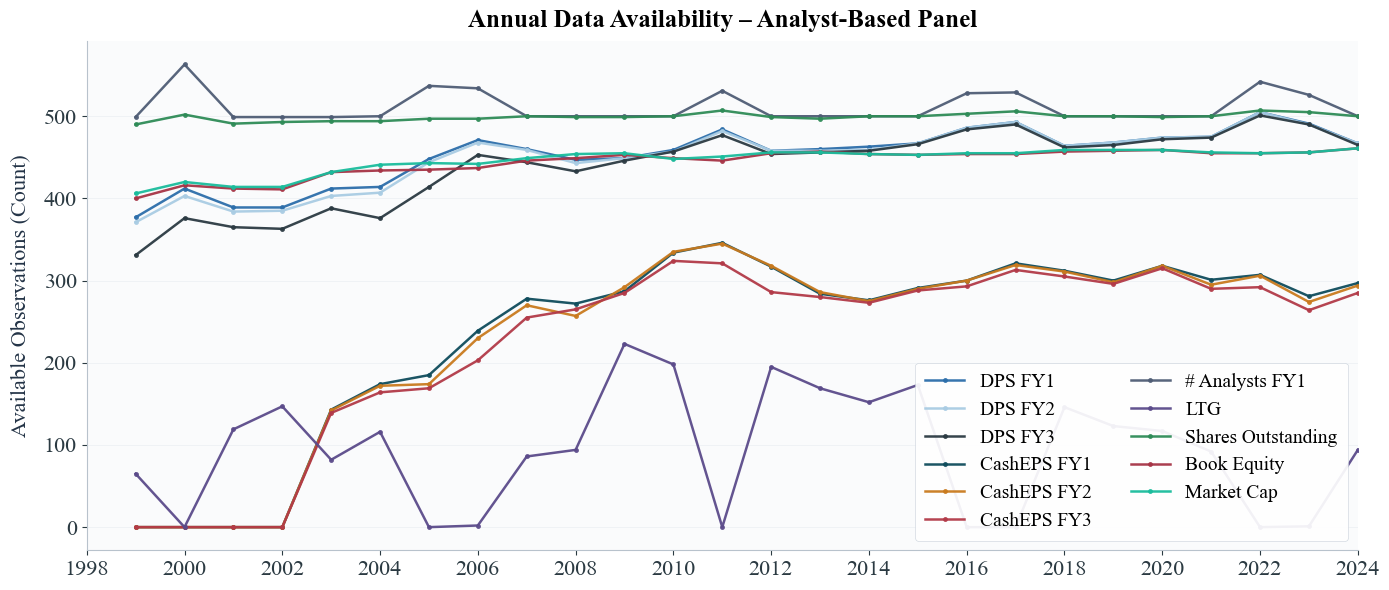


Coverage share per year (non-null / total rows):


,DPS_fy1_est,DPS_fy2_est,DPS_fy3_est,CFPS_fy1_est,CFPS_fy2_est,CFPS_fy3_est,NumAnalysts_fy1,LTG_est,shares_outstanding,BE,ME
year,,,,,,,,,,,
1999,0.754,0.742,0.662,0.000,0.000,0.000,0.998,0.130,0.980,0.800,0.812
2000,0.730,0.715,0.667,0.000,0.000,0.000,0.998,0.000,0.890,0.738,0.745
2001,0.778,0.768,0.730,0.000,0.000,0.000,0.998,0.238,0.982,0.824,0.828
2002,0.778,0.770,0.726,0.000,0.000,0.000,0.998,0.294,0.986,0.822,0.828
2003,0.824,0.806,0.776,0.286,0.284,0.278,0.998,0.164,0.988,0.864,0.864
2004,0.828,0.814,0.752,0.348,0.344,0.328,1.000,0.232,0.988,0.868,0.882
2005,0.831,0.824,0.768,0.343,0.323,0.314,0.996,0.000,0.922,0.807,0.822
2006,0.879,0.873,0.845,0.446,0.429,0.379,0.996,0.004,0.927,0.815,0.825
2007,0.920,0.918,0.888,0.556,0.540,0.510,1.000,0.172,1.000,0.892,0.898


In [10]:
# --- Coverage Plot (Annual Absolute Availability) ---
plot_cols = [
    ('DPS_fy1_est',      'DPS FY1'),
    ('DPS_fy2_est',      'DPS FY2'),
    ('DPS_fy3_est',      'DPS FY3'),
    ('CFPS_fy1_est',     'CashEPS FY1'),
    ('CFPS_fy2_est',     'CashEPS FY2'),
    ('CFPS_fy3_est',     'CashEPS FY3'),
    ('NumAnalysts_fy1',  '# Analysts FY1'),
    ('LTG_est',          'LTG'),
    ('shares_outstanding', 'Shares Outstanding'),
    ('BE',               'Book Equity'),
    ('ME',               'Market Cap'),
]

line_colors = [
    COLORS['blue'],
    COLORS['blue_light'],
    COLORS['reference'],
    COLORS['primary'],
    COLORS['orange'],
    COLORS['accent'],
    COLORS['neutral'],
    COLORS['purple'],
    COLORS['green'],
    COLORS.get('red', '#E74C3C'),
    COLORS.get('teal', '#1ABC9C'),
]

plot_df = analyst_df.copy()
plot_df['date'] = pd.to_datetime(plot_df['date'], errors='coerce')
plot_df = plot_df.dropna(subset=['firm_id', 'date']).copy()
plot_df['year'] = plot_df['date'].dt.year
plot_df = plot_df[plot_df['year'] <= 2024]

agg = plot_df.groupby('year', as_index=False).size().rename(columns={'size': 'n_rows'})
for col, _ in plot_cols:
    if col in plot_df.columns:
        agg[f'n_{col}'] = (
            plot_df.groupby('year')[col]
            .apply(lambda s: pd.to_numeric(s, errors='coerce').notna().sum() if col not in {'FiscalYearEnd', 'FYE_fy1'} else s.notna().sum())
            .reindex(agg['year'])
            .values
        )
    else:
        agg[f'n_{col}'] = 0

fig, ax = plt.subplots(figsize=(14, 6))

for (col, label), color in zip(plot_cols, line_colors):
    key = f'n_{col}'
    if key not in agg.columns:
        continue
    ax.plot(
        agg['year'], agg[key],
        label=label,
        color=color,
        linewidth=1.8,
        marker='o',
        markersize=3.5,
        markeredgewidth=0.0,
        alpha=0.95,
    )

ax.set_title('Annual Data Availability – Analyst-Based Panel')
ax.set_ylabel('Available Observations (Count)')

style_axes(ax, grid_axis='y', grid_alpha=0.3)
min_yr = 1998
max_yr = 2024
ax.set_xlim(min_yr, max_yr)
ax.set_xticks(list(range(min_yr, max_yr + 1, 2)))
ax.legend(
    loc='lower right',
    ncol=2,
    frameon=True,
    facecolor=(1.0, 1.0, 1.0, 0.82),
    edgecolor='#C4CDD7',
    framealpha=0.92,
    fancybox=True,
    borderpad=0.55,
)

graphs_dir = BASE_DIR / 'graphs' / 'LSEG_DataPull_AnalystBased'
graphs_dir.mkdir(parents=True, exist_ok=True)
fig.tight_layout()
_ps_save_figure(fig, graphs_dir / 'analystbased_coverage_annual.png', dpi=220)
plt.show()

# --- Numeric summary table ---
print('\nCoverage share per year (non-null / total rows):')
summary_cols = [col for col, _ in plot_cols if col in plot_df.columns]
cov = plot_df.assign(year=plot_df['date'].dt.year).groupby('year')[summary_cols].apply(lambda g: g.notna().mean()).round(3)
display(cov)

## 8. Output speichern

In [11]:
keep_cols = [
    'firm_id', 'date',
    'DPS_fy1_est', 'DPS_fy2_est', 'DPS_fy3_est',
    'CFPS_fy1_est', 'CFPS_fy2_est', 'CFPS_fy3_est',
    'NumAnalysts_fy1', 'NumAnalysts_fy2', 'NumAnalysts_fy3', 'NumAnalysts_fy4', 'NumAnalysts_fy5',
    'LTG_est',
    'FYE_fy1',
    'FiscalYearEnd',
    'shares_outstanding',
    'BE', 'ME',
]
existing_keep = [c for c in keep_cols if c in analyst_df.columns]
out = analyst_df[existing_keep].copy()
out = out[out['date'].dt.year <= 2024].sort_values(['firm_id', 'date']).reset_index(drop=True)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
out.to_parquet(OUTPUT_PATH, index=False)
print('Saved:', OUTPUT_PATH)
print('rows=', len(out), '| companies=', out['firm_id'].nunique(), '| date range:', out['date'].min(), '->', out['date'].max())

# ---------- Validate year coverage ----------
years_in_output = out['date'].dt.year.unique()
print(f"\nYears in output: {sorted(years_in_output)}")
missing_in_output = [y for y in range(1999, 2025) if y not in years_in_output]
if missing_in_output:
    print(f"WARNING: Still missing years: {missing_in_output}")
else:
    print("OK: All years 1999-2024 present in output.")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_analystbased.parquet
rows= 13296 | companies= 1054 | date range: 1999-12-31 00:00:00 -> 2024-12-31 00:00:00

Years in output: [np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
OK: All years 1999-2024 present in output.
